# Model Evaluation
Evaluate the trained forecasting model.

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path('..').resolve()
MODEL_PATH = PROJECT_ROOT/'artifacts/models/temperature_forecaster.joblib'
FEATURE_PATH = PROJECT_ROOT/'data/gold/temperature_features.parquet'
print(PROJECT_ROOT)

C:\Users\ngota\OneDrive\Desktop\SPRING 2026\ECE 591 Project\ocean-ml-rag-spark-complete


In [2]:
features = pd.read_parquet(FEATURE_PATH)
features.head()

,row,value,source_variable,source_file,units,dataset_id,canonical_variable,normalized_value,normalized_unit,provenance_transform,lag_1,lag_3,lag_6,hour,dayofyear
0,1766296,285.4031,Temperature,data\raw\onc\onc_temperature.nc,K,onc,sea_water_temperature,12.2531,degC,canonicalize_and_normalize,12.2533,12.2550,12.2573,NaN,NaN
1,1766297,285.4039,Temperature,data\raw\onc\onc_temperature.nc,K,onc,sea_water_temperature,12.2539,degC,canonicalize_and_normalize,12.2531,12.2542,12.2567,NaN,NaN
2,1766298,285.4045,Temperature,data\raw\onc\onc_temperature.nc,K,onc,sea_water_temperature,12.2545,degC,canonicalize_and_normalize,12.2539,12.2533,12.2559,NaN,NaN
3,1766299,285.4060,Temperature,data\raw\onc\onc_temperature.nc,K,onc,sea_water_temperature,12.2560,degC,canonicalize_and_normalize,12.2545,12.2531,12.2550,NaN,NaN
4,1766300,285.4083,Temperature,data\raw\onc\onc_temperature.nc,K,onc,sea_water_temperature,12.2583,degC,canonicalize_and_normalize,12.2560,12.2539,12.2542,NaN,NaN


In [ ]:
bundle = joblib.load(MODEL_PATH)
model = bundle['model']
feature_cols = bundle['features']
print('Features:', feature_cols)

Features: ['row', 'value', 'lag_1', 'lag_3', 'lag_6', 'hour', 'dayofyear']


In [ ]:
target = 'normalized_value'
X = features[feature_cols]
y = features[target]
split = int(len(X) * 0.8)
X_test = X.iloc[split:]
y_test = y.iloc[split:]
pred = model.predict(X_test)

In [5]:
results = pd.DataFrame({
    'actual': y_test,
    'predicted': pred
})

results['error'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,error
2838337,13.7532,13.749991,0.003209
2838338,13.7520,13.749991,0.002009
2838339,13.7546,13.749991,0.004609
2838340,13.7547,13.749991,0.004709
2838341,13.7542,13.749991,0.004209


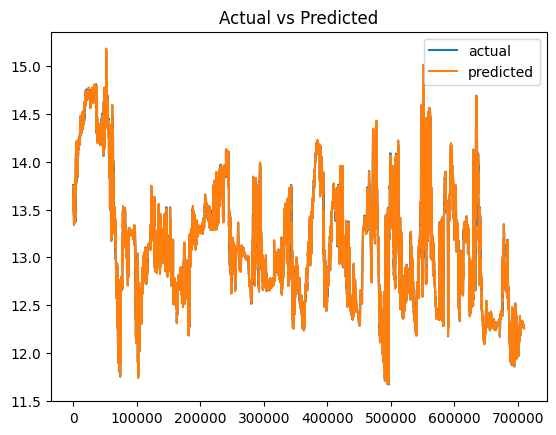

In [6]:
plt.plot(results['actual'].values, label='actual')
plt.plot(results['predicted'].values, label='predicted')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()

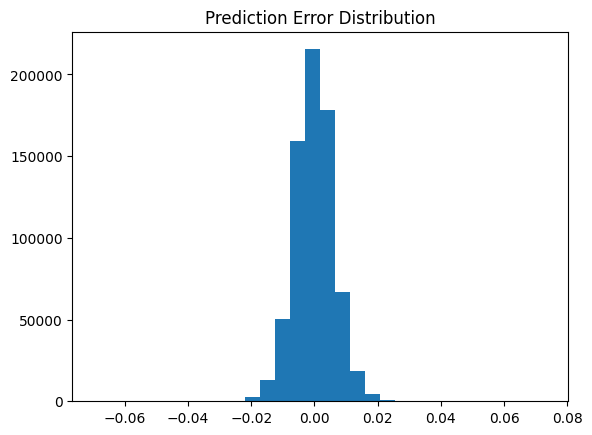

In [7]:
plt.hist(results['error'], bins=30)
plt.title('Prediction Error Distribution')
plt.show()